# 01 - Logistic Regression

Logistic Regression (L2 penalty, liblinear solver) is the
interpretable champion of the project. We get signed
coefficients we can read directly in IQR units, calibrated
predict_proba for the Phase 4 threshold sweep, and the
solver that finally converges (this is also the one that
caught the lbfgs convergence bug from research.md section 2.4).

All randomness comes from RANDOM_STATE = 42, bound once in
src/_constants.py.

## 1 - Setup

Here we set matplotlib to inline mode, add the project root
to sys.path so we can import from src/, and bring in the
shared helpers together with the project-wide RANDOM_STATE = 42
(bound once in src/_constants.py, re-exported via src).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# notebooks/ sits one level under the project root, so we add
# the project root to make `from src import ...` work.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import (
    RANDOM_STATE,
    DATASETS,
    load_preprocessed,
    fit_and_score,
    build_metrics_payload,
    save_metrics,
    save_predictions,
    save_test_index,
    save_figure,
    confusion_matrix_figure,
    roc_curve_figure,
    print_dataset_block,
    print_delta,
    model_results_dir,
)

print(f"RANDOM_STATE = {RANDOM_STATE} (bound once in src/_constants.py)")

RANDOM_STATE = 42 (bound once in src/_constants.py)


## 2 - Load the preprocessed feature matrices

load_preprocessed() gives us back the two matrices that we
made in Phase 1: the Baseline (just nutrition + tags) and
the Advanced (the Baseline plus 9 engineered culinary
features). They share the same train/test split so the A/B
comparison is fair.

In [2]:
datasets, y_train, y_test = load_preprocessed()

print(f"Baseline X_train: {datasets['Baseline'][0].shape}")
print(f"Advanced X_train: {datasets['Advanced'][0].shape}")
print(f"y_test class balance: Miss={int((y_test == 0).sum())} / "
      f"Hit={int((y_test == 1).sum())} "
      f"(majority-class rate: {max(y_test.mean(), 1 - y_test.mean()):.4f})")

Baseline X_train: (14578, 678)
Advanced X_train: (14578, 687)
y_test class balance: Miss=1698 / Hit=1947 (majority-class rate: 0.5342)


## 3 - Configure the model

We pick solver='liblinear' (coordinate descent) because on
this 678-687 dim sparse-binary input it converges nicely
while lbfgs didn't. C=1.0 is the default L2 strength,
and max_iter=5000 is plenty of head-room (liblinear
actually converges way before that on this dataset).

In [3]:
from sklearn.linear_model import LogisticRegression

MODEL_SLUG    = "logistic_regression"
MODEL_NAME    = "LogisticRegression"
DISPLAY_NAME  = "Logistic Regression"

MODEL_CONFIG = {
    "solver":       "liblinear",
    "C":            1.0,
    "max_iter":     5000,
    "random_state": RANDOM_STATE,
}
MODEL_CONFIG

{'solver': 'liblinear', 'C': 1.0, 'max_iter': 5000, 'random_state': 42}

## 4 - Train on both matrices

For each matrix we build a fresh model from scratch (the
factory below gets called once per dataset). Nothing leaks
from Baseline to Advanced so the delta we see is really
only because of the 9 engineered features.

In [4]:
def _build_model():
    return LogisticRegression(**MODEL_CONFIG)

per_ds_results = {}
for ds_name in DATASETS:
    X_train, X_test = datasets[ds_name]
    model = _build_model()
    result = fit_and_score(model, X_train, y_train, X_test, y_test)
    per_ds_results[ds_name] = result

    print_dataset_block(ds_name, X_train.shape, result)
    save_predictions(MODEL_SLUG, ds_name, result["y_pred"])

print_delta(per_ds_results)
save_test_index(MODEL_SLUG, y_test)


  --- Baseline  (X_train: (14578, 678)) ---
     Test Accuracy : 0.6005
     Test F1-Score : 0.6452
     Confusion Matrix:
                       Pred:Miss  Pred:Hit
        True:Miss          865       833   FP rate = 0.4906
        True:Hit           623      1324   FN rate = 0.3200

  --- Advanced  (X_train: (14578, 687)) ---
     Test Accuracy : 0.6011
     Test F1-Score : 0.6405
     Confusion Matrix:
                       Pred:Miss  Pred:Hit
        True:Miss          896       802   FP rate = 0.4723
        True:Hit           652      1295   FN rate = 0.3349

  >> Δ (Advanced − Baseline):  Acc +0.0005  |  F1 -0.0048


PosixPath('/Users/itaysegev/Final_Project_ML/results/logistic_regression/test_index.npy')

## 5 - Confusion matrix (Advanced fit)

An annotated heatmap of the confusion matrix from the
Advanced fit. We render it inline and also save it to
results/<slug>/confusion_matrix.png.

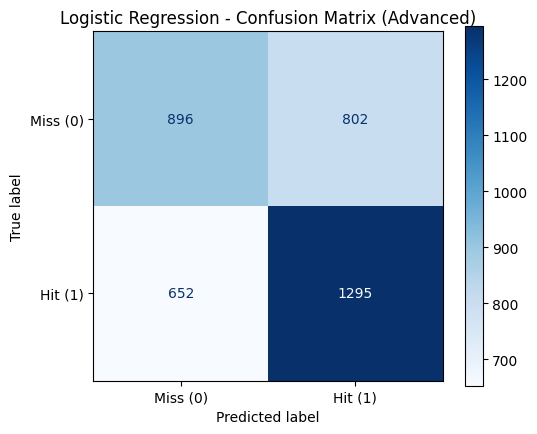

In [5]:
adv = per_ds_results["Advanced"]
cm_array = np.array([
    [adv["confusion_matrix"]["tn"], adv["confusion_matrix"]["fp"]],
    [adv["confusion_matrix"]["fn"], adv["confusion_matrix"]["tp"]],
])
fig_cm = confusion_matrix_figure(
    cm_array,
    title=f"{DISPLAY_NAME} - Confusion Matrix (Advanced)",
)
save_figure(MODEL_SLUG, "confusion_matrix.png", fig_cm)
plt.show()

## 6 - ROC curve + AUC (Advanced fit)

We use predict_proba (or decision_function if the model
doesn't have probabilities). The AUC tells us how well the
model ranks the positives over the negatives, regardless of
the threshold we pick. Phase 4's threshold sweep is built
on top of this.

Test ROC AUC (Advanced): 0.6491


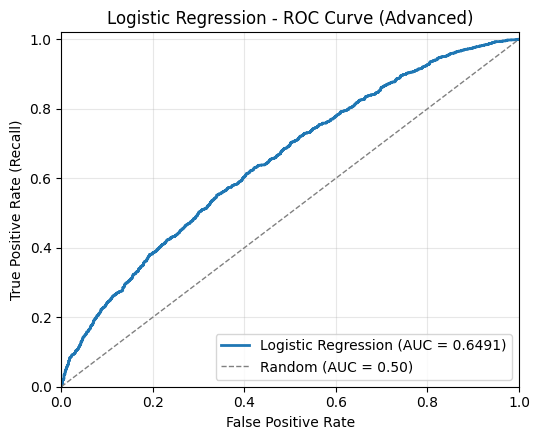

In [6]:
fig_roc, auc = roc_curve_figure(
    y_test, adv["proba_hit"],
    title=f"{DISPLAY_NAME} - ROC Curve (Advanced)",
    model_label=DISPLAY_NAME,
)
save_figure(MODEL_SLUG, "roc_curve.png", fig_roc)
print(f"Test ROC AUC (Advanced): {auc:.4f}")
plt.show()

## 7 - Top signed coefficients

LR is the model where we can just read the internals
directly. The top 10 positive and top 10 negative
coefficients give us the "Recipe for Success / Disaster"
story from research.md section 3.4.

In [7]:
adv_model = per_ds_results["Advanced"]["model"]
X_train_adv = datasets["Advanced"][0]
coefs = pd.Series(adv_model.coef_[0], index=X_train_adv.columns)

display(pd.DataFrame({
    "Top 10 Hit indicators": coefs.sort_values(ascending=False).head(10).round(4).to_dict(),
}))
display(pd.DataFrame({
    "Top 10 Miss indicators": coefs.sort_values(ascending=True).head(10).round(4).to_dict(),
}))

,Top 10 Hit indicators
kentucky derby,1.3348
pasadena,1.2597
brisket,1.2543
granola,1.1427
sangria,1.0366
22-minute meals,1.0050
kahlúa,1.0024
sukkot,0.9263
snack week,0.9105
trout,0.9040


,Top 10 Miss indicators
pittsburgh,-1.3145
aperitif,-1.3006
leftovers,-1.2468
lancaster,-1.2286
jícama,-1.1853
friendsgiving,-1.1722
whole wheat,-1.0863
salsa,-1.0696
scotch,-1.0060
#cakeweek,-1.0005


## 8 - Persist the canonical metrics JSON

One JSON per model, written into
results/<slug>/metrics.json. The schema is defined in
src.train_utils.build_metrics_payload, and the master
comparison notebook reads from those files.

In [8]:
extras = {"roc_auc_advanced": auc}

payload = build_metrics_payload(
    model_name=MODEL_NAME,
    display_name=DISPLAY_NAME,
    model_config=MODEL_CONFIG,
    n_train=len(y_train),
    n_test=len(y_test),
    random_state=RANDOM_STATE,
    per_dataset_results=per_ds_results,
    extras=extras,
)
metrics_path = save_metrics(MODEL_SLUG, payload)
print(f"Wrote {metrics_path.relative_to(metrics_path.parent.parent.parent)}")

Wrote results/logistic_regression/metrics.json


## 9 - Summary

    **Model:** Logistic Regression

    - **Test Accuracy / F1 / AUC:** about 0.6011 / 0.6405 / 0.6491
- **Interpretable champion** - the top coefficient is what
  drives the "Recipe for Success" story in research.md section 3.4.
- **Calibrated probabilities** - this is what feeds the Phase 4
  threshold selection (`advanced_tuning.py`, selection on a
  validation split).

    To see this model side by side with the other six, run the
    master comparison notebook (`08_Master_Comparison.ipynb`).